# Projekt Klasyfikacji uczniow

# import bibliotek


In [67]:
# import wszytskich potrzebnych bibliotek
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression


# Eksploracja danych

In [68]:
data = pd.read_csv('data/Student_performance_data_edited.csv', index_col='IDStudenta', names=["IDStudenta", "Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa"], header=0)

#data = pd.read_csv('data/data.csv',index_col="IDStudenta",names=["IDStudenta","Wiek", "Plec", "Pochodzenie", "WyksztalcenieRodzica", "CzasSpedzonyNaNauceTyg.", "Nieobecnosci", "Tutoring", "WsparcieRodzicow", "ZajeciaPozalekcyjne", "Sport", "Muzyka", "Wolontariat", "SredniaKoncowa","Ocena"],header=0)

print("Mamy", data.shape[0], "wierszy i", data.shape[1], "kolumn")
data.head()


Mamy 2392 wierszy i 13 kolumn


,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,Female,Caucasian,Some College,19.833723,7,Yes,Moderate,0,0,1,0,2.929196
1002,22,Male,Caucasian,High School,15.408756,0,No,Low,0,0,0,0,3.042915
1003,19,Male,Asian,Bachelor's,4.210570,26,No,Moderate,0,0,0,0,0.112602
1004,21,Female,Caucasian,Bachelor's,10.028829,14,No,High,1,0,0,0,2.054218
1005,21,Female,Caucasian,Some College,4.672495,17,Yes,High,0,0,0,0,1.288061


In [69]:
data.describe()

,Wiek,CzasSpedzonyNaNauceTyg.,Nieobecnosci,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
count,2392.000000,2389.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,20.468645,9.773029,14.541388,0.383361,0.303512,0.196906,0.157191,1.906186
std,1.123798,5.652477,8.467417,0.486307,0.459870,0.397744,0.364057,0.915156
min,19.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,5.043640,7.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,20.000000,9.705614,15.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,21.000000,14.408321,22.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,22.000000,19.978094,29.000000,1.000000,1.000000,1.000000,1.000000,4.000000


Wnioski:
- Widzimy ze wartosci sa w formacie tekstowym a powinny byc numeryczne aby modele lepiej dzialaly
- kolumna z 'srednia' nie jest zaokraglona

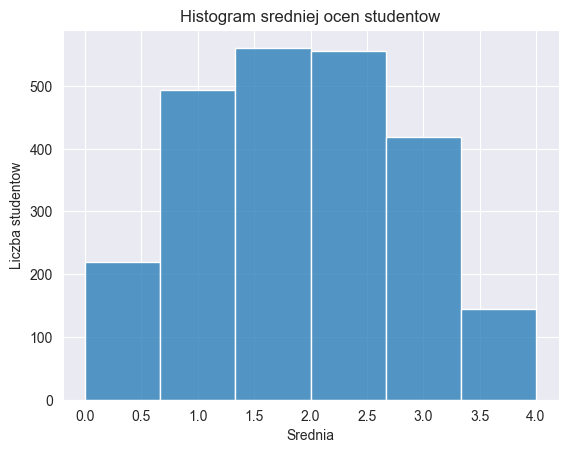

In [70]:
sns.histplot(data['SredniaKoncowa'], bins=6)
plt.xlabel('Srednia')
plt.ylabel('Liczba studentow')
plt.title('Histogram sredniej ocen studentow')
plt.show()

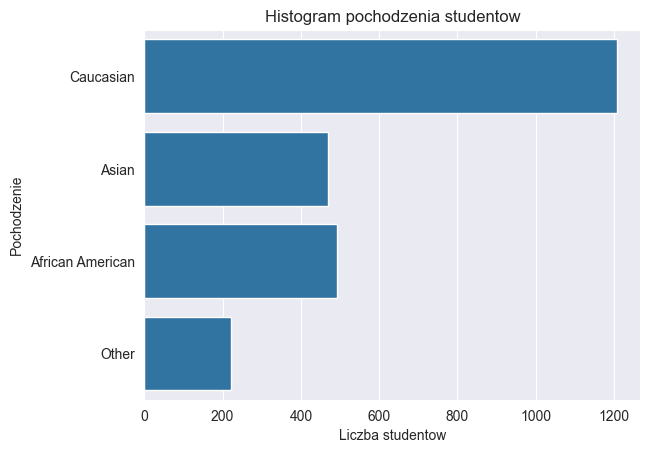

In [71]:
sns.countplot(data['Pochodzenie'])
plt.xlabel('Liczba studentow')
plt.ylabel('Pochodzenie')
plt.title('Histogram pochodzenia studentow')
plt.show()


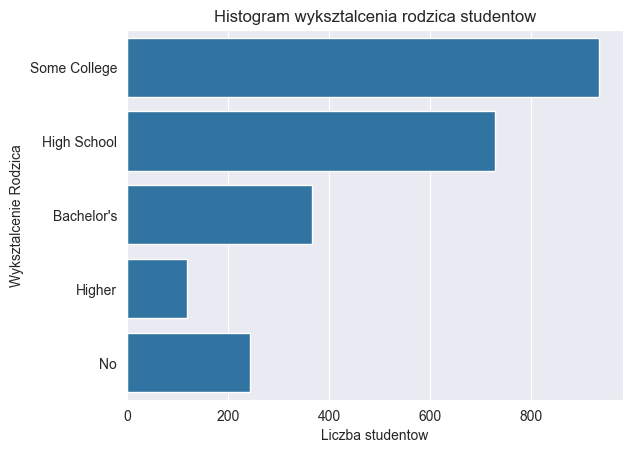

In [72]:
sns.countplot(data['WyksztalcenieRodzica'])
plt.xlabel('Liczba studentow')
plt.ylabel('Wyksztalcenie Rodzica')
plt.title('Histogram wyksztalcenia rodzica studentow')
plt.show()

# Preprocessing danych

## Uzupelnieie brakujacych wartosci

In [73]:
print(data.isnull().sum()[data.isnull().sum() > 0])
print()
print("Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić")
print()
data['CzasSpedzonyNaNauceTyg.'] = data['CzasSpedzonyNaNauceTyg.'].fillna(data['CzasSpedzonyNaNauceTyg.'].mean())
print(data.isnull().sum()[data.isnull().sum() > 0])

CzasSpedzonyNaNauceTyg.    3
dtype: int64

Widzimy rownież że mamy brakujacych wartosci ktore nalezy uzupełnić

Series([], dtype: int64)


Uzupelniamy na podstawie wartosci sredniej czasu spedznego na nauce Tygodniowo

## zamiana Wartosci tekstowych na numeryczne

In [74]:
labelEncoder = LabelEncoder()
data['Plec'] = labelEncoder.fit_transform(data['Plec']) # Female -> 0 Male ->1
data['Tutoring'] = labelEncoder.fit_transform(data['Tutoring']) # No -> 0 Yes -> 1

data.head()

,Wiek,Plec,Pochodzenie,WyksztalcenieRodzica,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,WsparcieRodzicow,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa
IDStudenta,,,,,,,,,,,,,
1001,21,0,Caucasian,Some College,19.833723,7,1,Moderate,0,0,1,0,2.929196
1002,22,1,Caucasian,High School,15.408756,0,0,Low,0,0,0,0,3.042915
1003,19,1,Asian,Bachelor's,4.210570,26,0,Moderate,0,0,0,0,0.112602
1004,21,0,Caucasian,Bachelor's,10.028829,14,0,High,1,0,0,0,2.054218
1005,21,0,Caucasian,Some College,4.672495,17,1,High,0,0,0,0,1.288061


## 1. Zamiana za pomoca LabelEncoder

In [75]:
# data['Pochodzenie'] = labelEncoder.fit_transform(data['Pochodzenie'])
# data['WyksztalcenieRodzica'] = labelEncoder.fit_transform(data['WyksztalcenieRodzica'])
# data['WsparcieRodzicow'] = labelEncoder.fit_transform(data['WsparcieRodzicow'])
#
# data.head()

In [76]:
# corr = data.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
# plt.title('Macierz korelacji')
# plt.show()

## 2. Zamiana za pomoca OneHotEncoder

In [77]:
oneHotEncoder = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder2 = OneHotEncoder(sparse_output=False, drop='first')
oneHotEncoder3 = OneHotEncoder(sparse_output=False, drop='first')
pochodzenieMatrix = oneHotEncoder.fit_transform(data[['Pochodzenie']])
wyksztalcenieMatrix = oneHotEncoder2.fit_transform(data[['WyksztalcenieRodzica']])
wsparcieRodzicowMatrix = oneHotEncoder3.fit_transform(data[['WsparcieRodzicow']])

pochodzenieDF = pd.DataFrame(pochodzenieMatrix, columns=oneHotEncoder.get_feature_names_out(['Pochodzenie']))
wyksztalcenieDF = pd.DataFrame(wyksztalcenieMatrix, columns=oneHotEncoder2.get_feature_names_out(['WyksztalcenieRodzica']))
wsparcieRodzicowDF = pd.DataFrame(wsparcieRodzicowMatrix, columns=oneHotEncoder3.get_feature_names_out(['WsparcieRodzicow']))

pochodzenieDF.index = data.index
wyksztalcenieDF.index = data.index
wsparcieRodzicowDF.index = data.index

data = pd.concat([data, pochodzenieDF, wyksztalcenieDF, wsparcieRodzicowDF], axis=1)
data.drop(columns=['Pochodzenie', 'WyksztalcenieRodzica', 'WsparcieRodzicow'], inplace=True)

data.head()

,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,SredniaKoncowa,...,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,,
1001,21,0,19.833723,7,1,0,0,1,0,2.929196,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1002,22,1,15.408756,0,0,0,0,0,0,3.042915,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1003,19,1,4.210570,26,0,0,0,0,0,0.112602,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1004,21,0,10.028829,14,0,1,0,0,0,2.054218,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1005,21,0,4.672495,17,1,0,0,0,0,1.288061,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


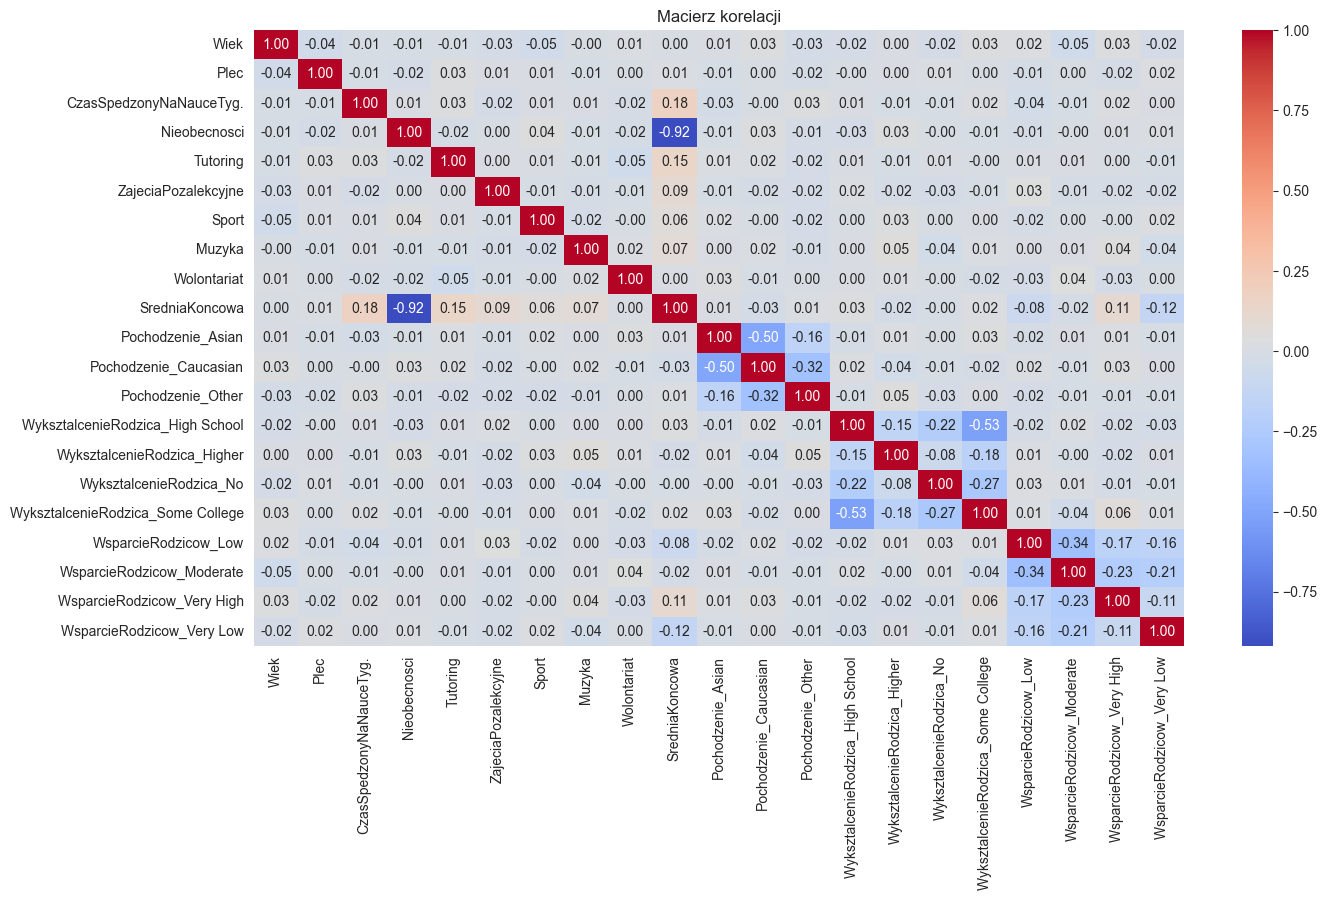

In [78]:
plt.figure(figsize=(15, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.show()

# Do tego momentu wszytsko jest takie samo a teraz dzielimy na problem Klasyfikacji i regresji

## Regresja


### Podzial na zbior testowy i treningowy

In [79]:
X = data.drop(columns=['SredniaKoncowa'], axis=1)
y = data['SredniaKoncowa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
1643,22,0,18.118879,24,1,1,1,0,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2753,20,0,2.469271,19,0,0,0,0,1,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2402,21,1,3.456401,25,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3033,21,0,15.838131,25,1,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1991,20,1,1.045373,19,1,0,0,1,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Regresja liniowa

In [80]:
regresjaLiniowa = LinearRegression()
regresjaLiniowa.fit(X_train, y_train)

y_pred = regresjaLiniowa.predict(X_test)

print("r2", regresjaLiniowa.score(X_test, y_test))
print("mean absolute error", mean_absolute_error(y_test, y_pred))

r2 0.953396608823332
mean absolute error 0.15505678108783794


### Regresja logistyczna


In [81]:
regresjaLogistyczna = LogisticRegression()
regresjaLogistyczna.fit(X_train, y_train)

y_pred = regresjaLogistyczna.predict(X_test)
print(y_train)

print("accuracy:", accuracy_score(y_test, y_pred))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

## Klasyfikacja

### Dokonujemy Dyskredytacje aby pozniej zrobic klasyfikacje

czyli robimy przedziały z dokładnych srednich ocen

In [91]:
# def licz_ocene(srednia):
#     procent = (srednia - 2.0) / 3.0 * 100
#
#     if procent < 50:
#         ocena = 2.0
#     elif procent < 60:
#         ocena = 3.0
#     elif procent < 70:
#         ocena = 3.5
#     elif procent < 80:
#         ocena = 4.0
#     elif procent < 90:
#         ocena = 4.5
#     else:
#         ocena = 5.0
#     return ocena
#
# data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
# data[['SredniaKoncowa', 'Ocena']].head()

def licz_ocene(srednia):
    if srednia >= 3.5:
        return 0  # A
    elif srednia >= 3.0:
        return 1  # B
    elif srednia >= 2.5:
        return 2  # C
    elif srednia >= 2.0:
        return 3  # D
    else:
        return 4  # F

data['Ocena'] = data['SredniaKoncowa'].apply(licz_ocene)
data[['SredniaKoncowa', 'Ocena']].head(10)


,SredniaKoncowa,Ocena
IDStudenta,,
1001,2.929196,2
1002,3.042915,1
1003,0.112602,4
1004,2.054218,3
1005,1.288061,4
1006,3.084184,1
1007,2.748237,2
1008,1.360143,4
1009,2.896819,2


### Podzial na zbior testowy i treningowy

In [84]:
X = data.drop(columns=['SredniaKoncowa', 'Ocena'])
y = data['Ocena']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Treningowy zbior:",X_train.shape)
print("Testowy zbior:",X_test.shape)

print()
X_train.head()

Treningowy zbior: (1913, 20)
Testowy zbior: (479, 20)



,Wiek,Plec,CzasSpedzonyNaNauceTyg.,Nieobecnosci,Tutoring,ZajeciaPozalekcyjne,Sport,Muzyka,Wolontariat,Pochodzenie_Asian,Pochodzenie_Caucasian,Pochodzenie_Other,WyksztalcenieRodzica_High School,WyksztalcenieRodzica_Higher,WyksztalcenieRodzica_No,WyksztalcenieRodzica_Some College,WsparcieRodzicow_Low,WsparcieRodzicow_Moderate,WsparcieRodzicow_Very High,WsparcieRodzicow_Very Low
IDStudenta,,,,,,,,,,,,,,,,,,,,
2513,19,1,4.459000,27,0,0,0,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1228,20,1,8.090390,27,0,0,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1658,21,0,17.531210,25,1,0,0,0,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1413,20,1,10.437246,19,1,1,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2234,19,0,7.599199,22,0,0,1,1,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### standaryzacja

In [85]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Zbior po standaryzacji")
print(np.mean(X_train, axis=0))
print(np.std(X_train, axis=0))

Zbior po standaryzacji
[ 9.22999842e-16 -8.31071287e-17 -9.65714121e-17  7.42857016e-17
 -3.71428508e-18  5.57142762e-18  7.24285591e-17 -2.32142817e-17
 -7.79999867e-17  6.68571314e-17  2.22857105e-17  5.10714198e-17
  7.42857016e-18  1.09107124e-16 -4.03928502e-17  4.64285635e-18
  6.77857027e-17 -2.41428530e-17  2.97142806e-17  5.57142762e-17]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Wyrownywanie wartosci Y

In [86]:
print(y_train.value_counts())

Ocena
4    1019
3     329
2     308
1     195
0      62
Name: count, dtype: int64


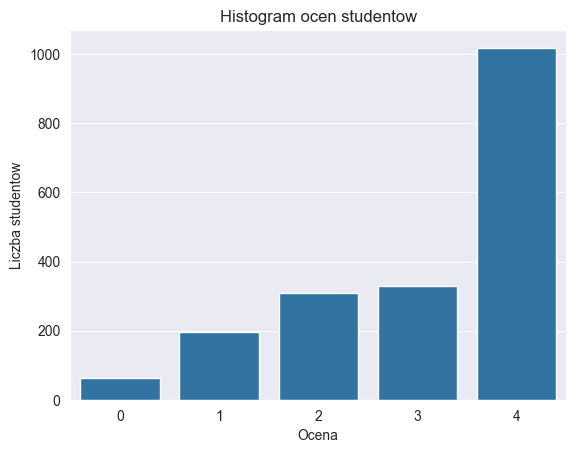

In [87]:
sns.countplot(x=y_train)
plt.xlabel('Ocena')
plt.ylabel('Liczba studentow')
plt.title('Histogram ocen studentow')
plt.show()

Widzimy ze mamy bardzo niezbalansowane dane

#### 1. Udersampling

In [88]:
# underSampler = RandomUnderSampler()
# y_train = y_train.astype(str)  # musimy zamienic na str poniewaz traktuje to jako ciagłe poniewaz mamy oceny 4,5 itd
#
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
#
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
#
# print("Zbalansowany zbior")
# print(y_train.value_counts())


#### 2. Oversampling

In [89]:
# oversampler = SMOTE()
# y_train = y_train.astype(str)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
#
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
#
# print("Zbalansowany zbior")
# print(y_train.value_counts())

#### 3. Undersampling + Oversampling

In [90]:
# underSampler = RandomUnderSampler(sampling_strategy='majority',random_state=42)
# oversampler = SMOTE(sampling_strategy='auto', random_state=42)
# y_train = y_train.astype(str)
# X_train, y_train = underSampler.fit_resample(X_train, y_train)
# X_train, y_train = oversampler.fit_resample(X_train, y_train)
# sns.countplot(x=y_train)
# plt.xlabel('Ocena')
# plt.ylabel('Liczba studentow')
# plt.title('Histogram ocen studentow')
# plt.show()
# print("Zbalansowany zbior")
# print(y_train.value_counts())
#
#
